In [34]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
from tqdm import tqdm

import os

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [35]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [36]:
# Reading in the full length sequences and tile data - PADI

data = pd.read_csv("Data/PADI/Unique_PADI_Seqs_three_clusters.csv", index_col=0)
test_seqs= data[data["cluster"] == 2]
val_seqs= data[data["cluster"] == 1]
train_seqs = data[data["cluster"] == 0]

tile_data = pd.read_csv("Data/PADI/PADI_ADScore_data_wrangled.csv")

activity_dict = {}
for i in tile_data.index:
    activity_dict[tile_data.loc[i,"aa_seq"]] = tile_data.loc[i,"activity"]

abund_dict = {}
for i in tile_data.index:
    abund_dict[tile_data.loc[i,"aa_seq"]] = tile_data.loc[i,"abundance"]

used_tiles = []

def get_tile_activity(tile):
    used_tiles.append(tile)
    return activity_dict.get(tile)

def get_tile_abundance(tile):
    return abund_dict.get(tile)


# Break full length seqs into tiles, adding in the final tile
test_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in test_seqs["Sequence"]]
test_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in test_seqs["Sequence"]]
test_seqs["40_tiles_exp_activities"] = [[get_tile_activity(tile) for tile in tiles] for tiles in test_seqs["40_tiles"]]
test_seqs["40_tiles_exp_abundance"] = [[get_tile_abundance(tile) for tile in tiles] for tiles in test_seqs["40_tiles"]]

val_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in val_seqs["Sequence"]]
val_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in val_seqs["Sequence"]]
val_seqs["40_tiles_exp_activities"] = [[get_tile_activity(tile) for tile in tiles] for tiles in val_seqs["40_tiles"]]
val_seqs["40_tiles_exp_abundance"] = [[get_tile_abundance(tile) for tile in tiles] for tiles in val_seqs["40_tiles"]]


train_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in train_seqs["Sequence"]]
train_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in train_seqs["Sequence"]]
train_seqs["40_tiles_exp_activities"] = [[get_tile_activity(tile) for tile in tiles] for tiles in train_seqs["40_tiles"]]
train_seqs["40_tiles_exp_abundance"] = [[get_tile_abundance(tile) for tile in tiles] for tiles in train_seqs["40_tiles"]]

unused_tiles = list(set(tile_data["aa_seq"]).difference(set(used_tiles)))
other_tiles = pd.DataFrame(unused_tiles, columns=["aa_seq"])
other_tiles["activity"] = [get_tile_activity(s) for s in other_tiles["aa_seq"]]
other_tiles["abundance"] = [get_tile_abundance(s) for s in other_tiles["aa_seq"]]


/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_63125/2897162465.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in test_seqs["Sequence"]]
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_63125/2897162465.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in test_seqs["Sequence"]]
/var/folders/3

In [37]:
# For two state model:
# This is an attempt to choose the "best" model in an unbiased way
# Specifically, it tries to choose a model that has both a high pearson and a high spearman correlation
# It does this by choosing the model with the highest combined spearman and pearson rank

two_model_results = pd.read_csv("results/PADI_results_two_state_test_leakyReLU.csv")
two_model_results['abund_k'] = [int(re.search(r'ak(\d+)',model).group(1)) for model in two_model_results['model_name']]
two_model_results = two_model_results.sort_values("pearson_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r1"] = two_model_results.index

two_model_results = two_model_results.sort_values("spearman_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r2"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")

two_model_results = two_model_results.sort_values("spearman_abund_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r4"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")


two_model_results["max_rank"] = two_model_results[["r1","r2","r4"]].max(axis=1)            # min–max rule
two_model_results["sum_rank"] = two_model_results["r1"] + two_model_results["r2"] + two_model_results["r4"]               # Borda

In [38]:
# For two state model:
# This is an attempt to choose the "best" model in an unbiased way
# Specifically, it tries to choose a model that has both a high pearson and a high spearman correlation
# It does this by choosing the model with the highest combined spearman and pearson rank

# two_model_results = pd.read_csv("results/results_two_state_test_larger_LR.csv")
# two_model_results = pd.read_csv("results/results_two_state_test_relu.csv")
two_model_results_gcn4 = pd.read_csv('results/results_two_state_test_leakyrelu.csv')
# two_model_results = two_model_results[two_model_results['kernel_size'] < 40]
two_model_results_gcn4 = two_model_results_gcn4.sort_values("pearson_act_val", ascending=False)
two_model_results_gcn4 = two_model_results_gcn4.reset_index()
two_model_results_gcn4["r1"] = two_model_results_gcn4.index

two_model_results_gcn4 = two_model_results_gcn4.sort_values("spearman_act_val", ascending=False)
two_model_results_gcn4 = two_model_results_gcn4.reset_index()
two_model_results_gcn4["r2"] = two_model_results_gcn4.index
two_model_results_gcn4 = two_model_results_gcn4.drop(columns="level_0")

two_model_results_gcn4 = two_model_results_gcn4.sort_values("pearson_abund_val", ascending=False)
two_model_results_gcn4 = two_model_results_gcn4.reset_index()
two_model_results_gcn4["r3"] = two_model_results_gcn4.index
two_model_results_gcn4 = two_model_results_gcn4.drop(columns="level_0")

two_model_results_gcn4 = two_model_results_gcn4.sort_values("spearman_abund_val", ascending=False)
two_model_results_gcn4 = two_model_results_gcn4.reset_index()
two_model_results_gcn4["r4"] = two_model_results_gcn4.index
two_model_results_gcn4 = two_model_results_gcn4.drop(columns="level_0")


two_model_results_gcn4["max_rank"] = two_model_results_gcn4[["r1", 'r4', 'r2']].max(axis=1)            # min–max rule
two_model_results_gcn4["sum_rank"] = two_model_results_gcn4["r1"] +  two_model_results_gcn4["r4"] + two_model_results_gcn4["r2"] #+ two_model_results["r3"]              # Borda

two_model_results_gcn4.sort_values(["sum_rank"], ascending=True)#["pearson_act_test"] #[['spearman_abund_test', 'spearman_act_test', 'pearson_abund_test', 'pearson_act_test']]

,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,...,K2_negative,abund_negative,relu,total_params,r1,r2,r3,r4,max_rank,sum_rank
38,1157,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Linear,0.5,0.1,1,0.559829,0.786183,...,NaN,False,False,1608,298,13,26,38,298,349
39,2597,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Linear,0.5,0.1,1,0.559829,0.786183,...,NaN,False,False,1608,297,14,27,39,297,350
64,2571,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,30,Linear,0.5,0.1,1,0.569510,0.777808,...,NaN,False,False,1038,175,114,13,64,175,353
65,1131,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,30,Linear,0.5,0.1,1,0.569510,0.777808,...,NaN,False,False,1038,176,113,12,65,176,354
317,713,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.569492,0.797700,...,NaN,False,False,1418,39,3,168,317,317,359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2535,2098,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,5,Hill,0.5,0.1,2,0.528138,0.725191,...,NaN,True,False,278,2795,2786,2579,2535,2795,8116
2537,2096,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,3,Hill,0.5,0.1,2,0.528138,0.708349,...,NaN,True,False,240,2818,2877,2581,2537,2877,8232
2814,1950,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,1,Hill,0.5,0.1,2,0.518811,0.757010,...,NaN,True,False,202,2759,2818,2834,2814,2818,8391
2824,1954,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,5,Hill,0.5,0.1,2,0.518811,0.731711,...,NaN,True,False,278,2878,2709,2816,2824,2878,8411


In [39]:
two_model_results[two_model_results['abund_k'] >= 5].sort_values("sum_rank").drop_duplicates()

,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,...,K2_negative,abund_negative,relu,total_params,abund_k,r1,r2,r4,max_rank,sum_rank
72,694,../../model_data/PADI_two_state_abundmodel_b10...,two_state_abund,35,Hill,0.1,0.5,1,0.348444,0.470098,...,NaN,False,False,1323,30,128,5,72,128,205
117,1137,../../model_data/PADI_two_state_abundmodel_b10...,two_state_abund,30,Hill,0.1,0.5,1,0.353433,0.465470,...,NaN,False,False,1323,35,21,105,117,117,243
119,1139,../../model_data/PADI_two_state_abundmodel_b10...,two_state_abund,40,Hill,0.1,0.5,1,0.353433,0.470644,...,NaN,False,False,1513,35,115,16,119,119,250
84,1114,../../model_data/PADI_two_state_abundmodel_b10...,two_state_abund,35,Hill,0.1,0.5,1,0.353199,0.470397,...,NaN,False,False,1228,25,39,166,84,166,289
96,1282,../../model_data/PADI_two_state_abundmodel_b10...,two_state_abund,35,Hill,0.1,0.5,1,0.357456,0.461564,...,NaN,False,False,1418,35,4,199,96,199,299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1369,649,../../model_data/PADI_two_state_abundmodel_b10...,two_state_abund,2,Hill,0.1,0.5,1,0.328222,0.384803,...,NaN,False,False,411,15,1410,1430,1369,1430,4209
1374,648,../../model_data/PADI_two_state_abundmodel_b10...,two_state_abund,1,Hill,0.1,0.5,1,0.328222,0.359465,...,NaN,False,False,392,15,1434,1434,1374,1434,4242
1420,516,../../model_data/PADI_two_state_abundmodel_b10...,two_state_abund,1,Hill,0.1,0.5,1,0.324955,0.371363,...,NaN,False,False,487,20,1424,1402,1420,1424,4246
1392,804,../../model_data/PADI_two_state_abundmodel_b10...,two_state_abund,1,Hill,0.1,0.5,1,0.322493,0.367925,...,NaN,False,False,487,20,1432,1428,1392,1432,4252


In [40]:
two_model_results[two_model_results["activity_fun"] == "Hill"].sort_values("sum_rank", ascending=True).reset_index().loc[0, "model_name"]

'../../model_data/PADI_two_state_abundmodel_b10_e200_L0.001_sMinMax_aHill_c1_k30_ak1_LeakyReLU_0.1PosKLoss_0.5PosWeightLoss_hSplit_hv1_seed3297062_weightInit'

In [41]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
relu = False
outchannel = 1

# Loading the "best" model, as defined above based on val data
# We also are filtering to use Hill value as that gave systematically better pearson correlations
best_two_model_row = two_model_results[(two_model_results["activity_fun"] == "Hill") & (two_model_results['abund_k'] >= 5) & (two_model_results['kernel_size'] == 40)].sort_values("sum_rank", ascending=True).reset_index()
model = best_two_model_row.loc[0, "model_name"].removeprefix("../../")
kernel_size_two = best_two_model_row.loc[0, "kernel_size"]
abund_k_two = int(re.search(r'ak(\d+)',model).group(1))
activity_fun = best_two_model_row.loc[0, "activity_fun"]
best_params = best_two_model_row.loc[0, "total_params"]

two_state_biophysical_model = ADModel_two_state_abund(size,activity_fun, kernel_size_two, relu=False, abund_k=abund_k_two)
two_state_biophysical_model.load_state_dict(torch.load(f"{model}.pth"))

two_state_biophysical_model.eval()

# Loading the scaler
sc_act = load("Model/PADI_scaler_activity.bin")
sc_abund = load("Model/PADI_scaler_abund.bin")


def run_biophysical_model(loaded_model,sequence):
    """
    Takes a sequence and run the model on sequence
    """
    encoded_seq = one_hot_encode(sequence).reshape(1,1,40,20)
    seq_tensor = torch.from_numpy(encoded_seq).type(torch.FloatTensor)
    predictions = loaded_model(seq_tensor)
    predictions_act = sc_act.inverse_transform(predictions.detach().numpy().reshape(-1)[1].reshape(1,-1))
    predictions_abund = sc_abund.inverse_transform(predictions.detach().numpy().reshape(-1)[0].reshape(1,-1))
    return predictions_abund, predictions_act

# Run biophysical model on all the sequences
test_seqs["biophysics_gfp_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tiles] for tiles in tqdm(test_seqs["40_tiles"])]
val_seqs["biophysics_gfp_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tiles] for tiles in tqdm(val_seqs["40_tiles"])]
train_seqs["biophysics_gfp_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tiles] for tiles in tqdm(train_seqs["40_tiles"])]
other_tiles["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tqdm(other_tiles["aa_seq"])]

test_seqs["biophysics_mcherry_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[0] for tile in tiles] for tiles in tqdm(test_seqs["40_tiles"])]
val_seqs["biophysics_mcherry_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[0] for tile in tiles] for tiles in tqdm(val_seqs["40_tiles"])]
train_seqs["biophysics_mcherry_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[0] for tile in tiles] for tiles in tqdm(train_seqs["40_tiles"])]
other_tiles["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0] for tile in tqdm(other_tiles["aa_seq"])]


100%|██████████| 253/253 [00:03<00:00, 69.27it/s]
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_63125/757701673.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["biophysics_gfp_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tiles] for tiles in tqdm(test_seqs["40_tiles"])]
100%|██████████| 184/184 [00:02<00:00, 65.18it/s]
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_63125/757701673.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-cop

In [42]:
two_model_results_gcn4.sort_values("sum_rank", ascending=True)

,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,...,K2_negative,abund_negative,relu,total_params,r1,r2,r3,r4,max_rank,sum_rank
38,1157,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Linear,0.5,0.1,1,0.559829,0.786183,...,NaN,False,False,1608,298,13,26,38,298,349
39,2597,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Linear,0.5,0.1,1,0.559829,0.786183,...,NaN,False,False,1608,297,14,27,39,297,350
64,2571,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,30,Linear,0.5,0.1,1,0.569510,0.777808,...,NaN,False,False,1038,175,114,13,64,175,353
65,1131,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,30,Linear,0.5,0.1,1,0.569510,0.777808,...,NaN,False,False,1038,176,113,12,65,176,354
317,713,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.569492,0.797700,...,NaN,False,False,1418,39,3,168,317,317,359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2535,2098,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,5,Hill,0.5,0.1,2,0.528138,0.725191,...,NaN,True,False,278,2795,2786,2579,2535,2795,8116
2537,2096,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,3,Hill,0.5,0.1,2,0.528138,0.708349,...,NaN,True,False,240,2818,2877,2581,2537,2877,8232
2814,1950,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,1,Hill,0.5,0.1,2,0.518811,0.757010,...,NaN,True,False,202,2759,2818,2834,2814,2818,8391
2824,1954,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,5,Hill,0.5,0.1,2,0.518811,0.731711,...,NaN,True,False,278,2878,2709,2816,2824,2878,8411


In [43]:
two_model_results_gcn4[(two_model_results_gcn4["activity_fun"] == "Hill") & (two_model_results_gcn4["spearman_abund_val"] > 0.5) ].sort_values("sum_rank", ascending=True).reset_index()

,level_0,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,...,K2_negative,abund_negative,relu,total_params,r1,r2,r3,r4,max_rank,sum_rank
0,317,713,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.569492,...,NaN,False,False,1418,39,3,168,317,317,359
1,279,197,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.566106,...,NaN,False,False,1228,84,25,235,279,279,388
2,269,196,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,35,Hill,0.5,0.1,1,0.566106,...,NaN,False,False,1133,278,66,221,269,278,613
3,512,581,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.558325,...,NaN,False,False,1608,117,2,786,512,512,631
4,332,2153,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,2,0.569492,...,NaN,False,False,1418,27,405,175,332,405,764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1417,2535,2098,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,5,Hill,0.5,0.1,2,0.528138,...,NaN,True,False,278,2795,2786,2579,2535,2795,8116
1418,2537,2096,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,3,Hill,0.5,0.1,2,0.528138,...,NaN,True,False,240,2818,2877,2581,2537,2877,8232
1419,2814,1950,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,1,Hill,0.5,0.1,2,0.518811,...,NaN,True,False,202,2759,2818,2834,2814,2818,8391
1420,2824,1954,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,5,Hill,0.5,0.1,2,0.518811,...,NaN,True,False,278,2878,2709,2816,2824,2878,8411


In [44]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
relu = False
outchannel = 1

# Loading the "best" model, as defined above based on val data
# We also are filtering to use Hill value as that gave systematically better pearson correlations
best_two_model_row = two_model_results_gcn4[(two_model_results_gcn4["activity_fun"] == "Hill") & (two_model_results_gcn4["spearman_abund_val"] > 0.5) ].sort_values("sum_rank", ascending=True).reset_index()
model = best_two_model_row.loc[0, "model_name"].removeprefix("../../")
kernel_size_two_gcn4 = best_two_model_row.loc[0, "kernel_size"]
abund_k_two_gcn4 = int(re.search(r'ak(\d+)',model).group(1))
activity_fun = best_two_model_row.loc[0, "activity_fun"]

two_state_biophysical_model_gcn4 = ADModel_two_state_abund(size,activity_fun, kernel_size_two_gcn4, relu=False, abund_k=abund_k_two_gcn4)
two_state_biophysical_model_gcn4.load_state_dict(torch.load(f"{model}.pth"))

two_state_biophysical_model_gcn4.eval()


ADModel_two_state_abund(
  (conv2): Conv2d(1, 1, kernel_size=(30, 20), stride=(1, 1))
  (linear2): Linear(in_features=11, out_features=1, bias=True)
  (conv1): Conv2d(1, 1, kernel_size=(40, 20), stride=(1, 1))
  (linear1): Linear(in_features=1, out_features=1, bias=True)
  (activate1): LeakyReLU(negative_slope=0.01)
  (activate2): LeakyReLU(negative_slope=0.01)
  (activate3): LeakyReLU(negative_slope=0.01)
  (activate4): LeakyReLU(negative_slope=0.01)
  (transf): HillActivation()
  (sigmoid): Sigmoid()
)

# Evaluating model performance

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


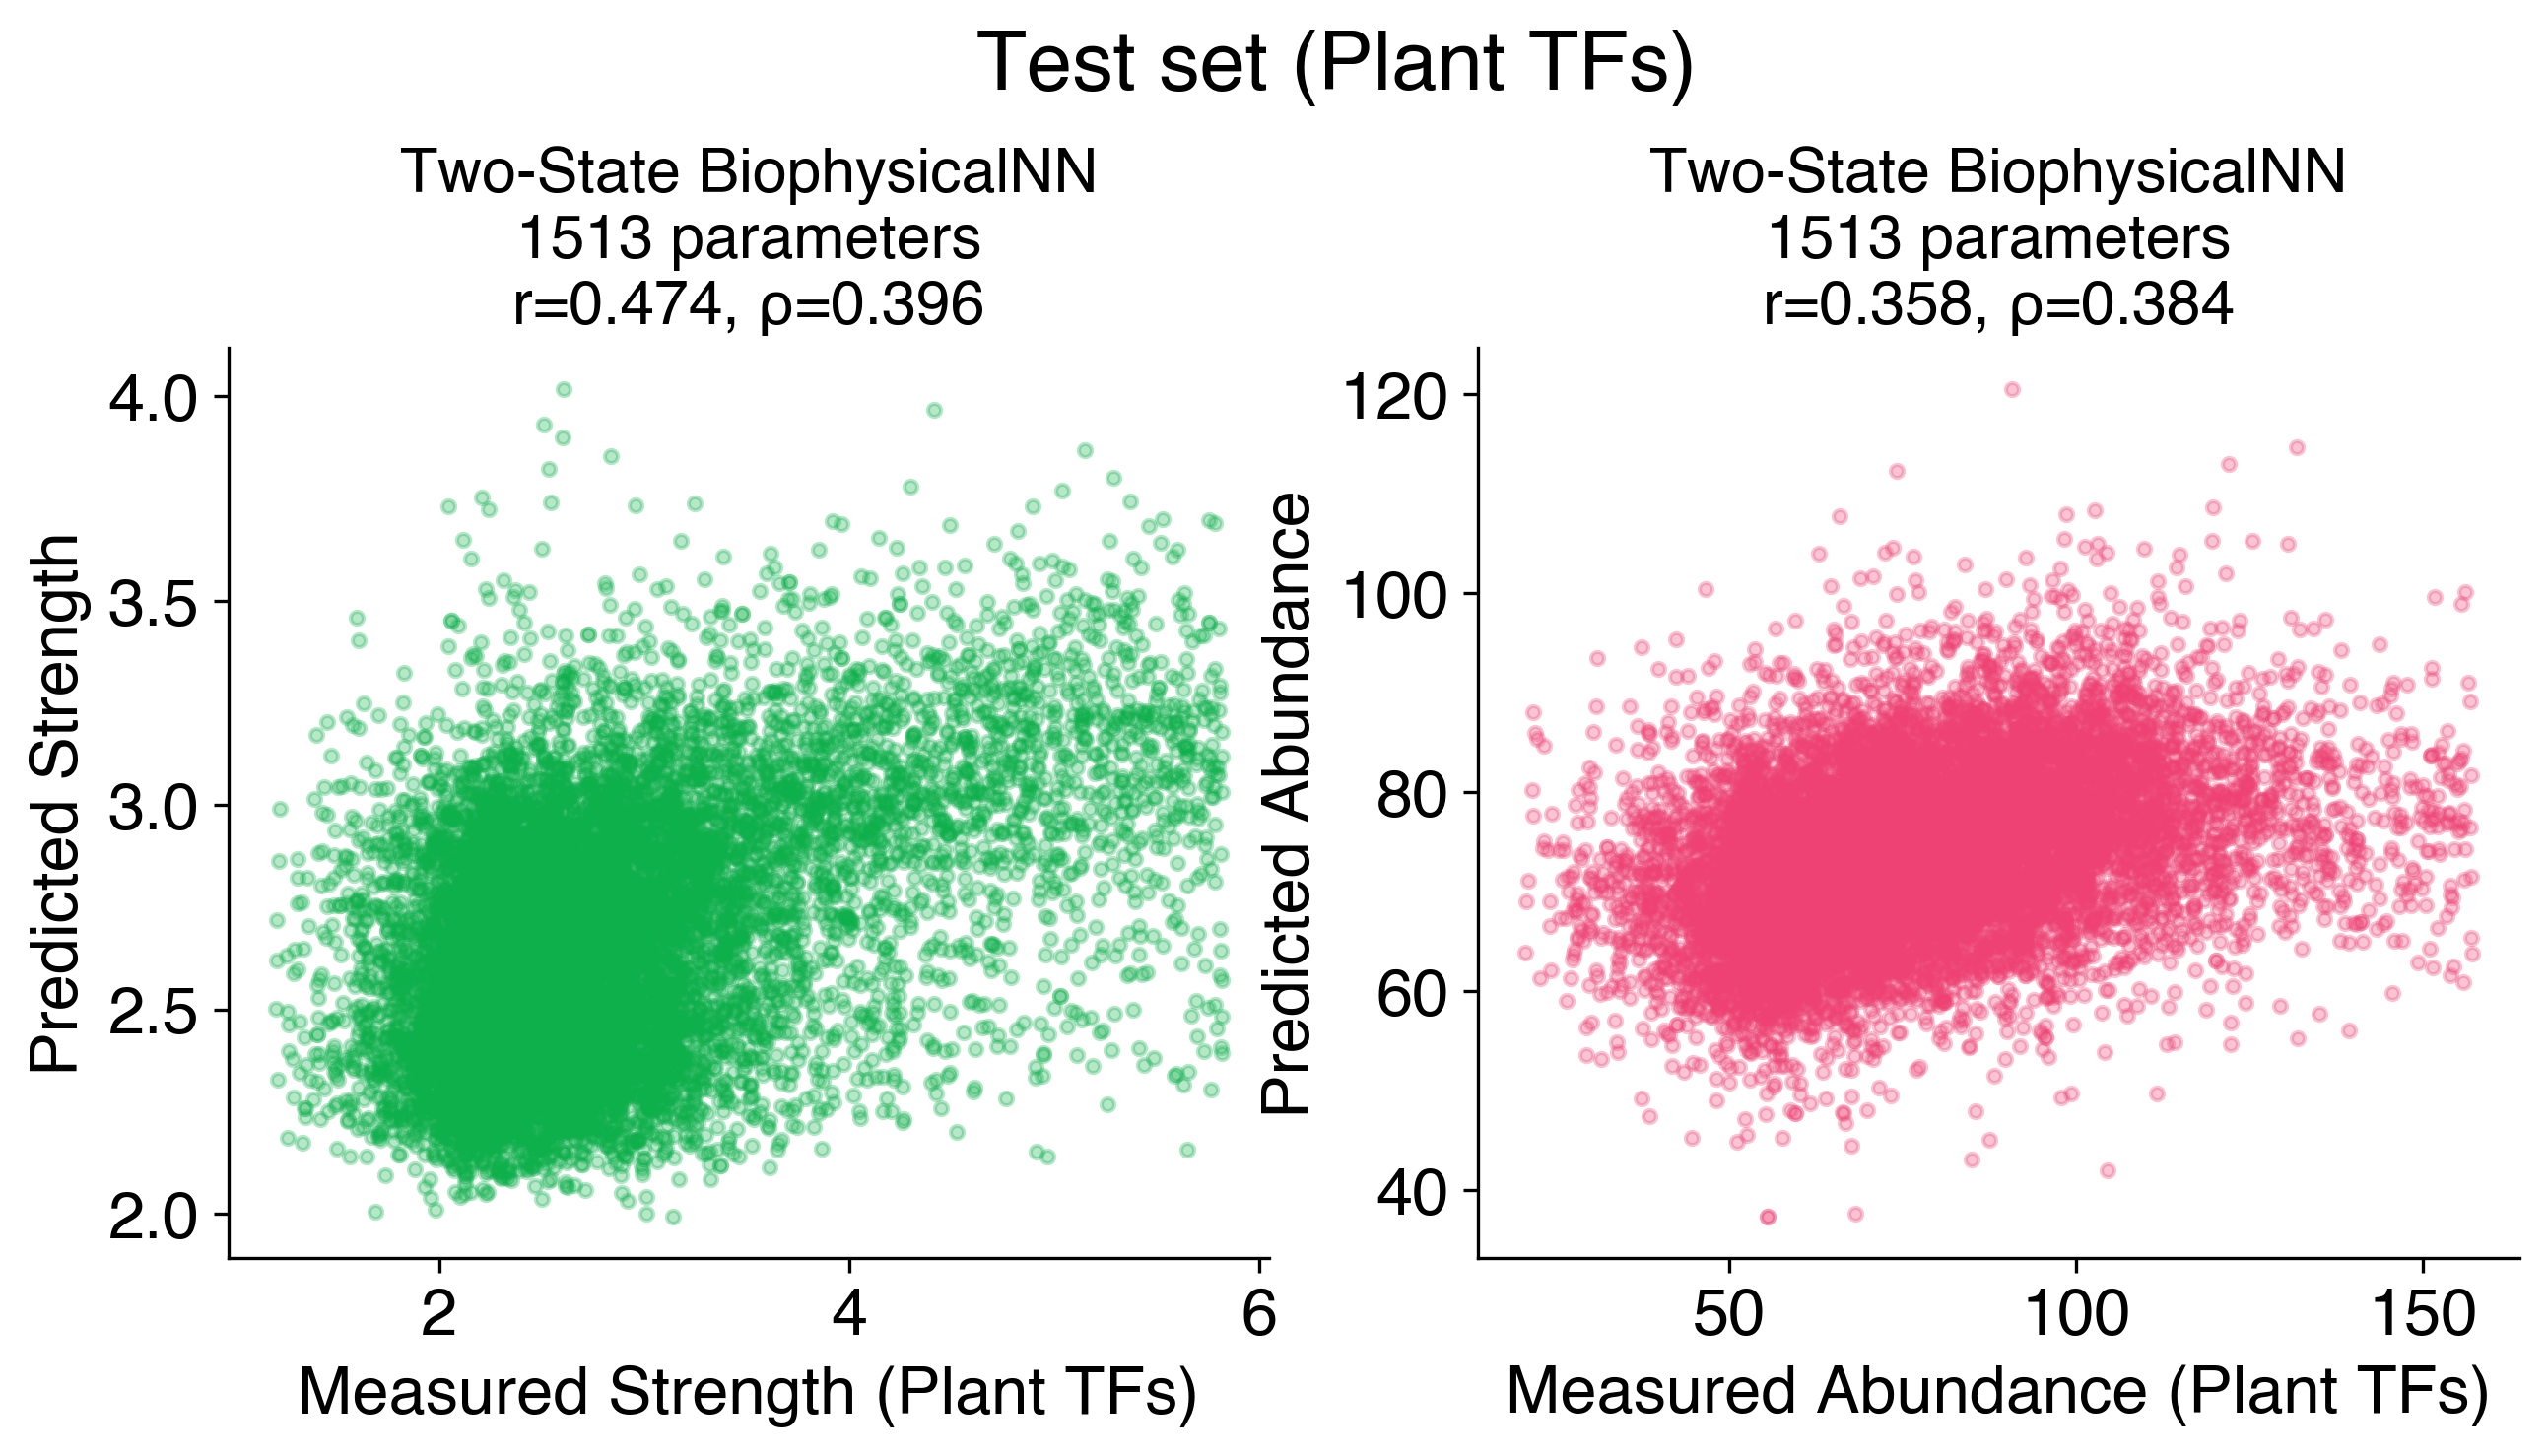

In [45]:
# Code to plot scatter plots for two-state BiophysicalNN, and ADHunter

fig, axs = plt.subplots(1,2,figsize=(10,4))

# Scatter plot for two-state BiophysicalNN - GFP
tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
tiles = tiles + (list(other_tiles["aa_seq"]))
actual = [i for ls in test_seqs["40_tiles_exp_activities"] for i in ls]
actual = actual + (list(other_tiles["activity"]))
pred = [i for ls in test_seqs["biophysics_gfp_pred_2"] for i in ls]
pred = pred + (list(other_tiles["biophysics_gfp_pred_2"]))
plotting_data = pd.DataFrame((actual, pred, tiles)).T
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[0].scatter(actual, pred, color='#0DB04B', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[0].set_xlabel('Measured Strength (Plant TFs)', fontsize=16)
axs[0].set_ylabel('Predicted Strength', fontsize=16)
axs[0].set_title("Two-State BiophysicalNN" + f'\n{best_params} parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)
axs[0].tick_params(labelsize=16)

# Scatter plot for two-state BiophysicalNN - mCherry
tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
tiles = tiles + (list(other_tiles["aa_seq"]))
actual = [i for ls in test_seqs["40_tiles_exp_abundance"] for i in ls]
actual = actual + (list(other_tiles["abundance"]))
pred = [i for ls in test_seqs["biophysics_mcherry_pred_2"] for i in ls]
pred = pred + (list(other_tiles["biophysics_mcherry_pred_2"]))
plotting_data = pd.DataFrame((actual, pred, tiles)).T
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[1].scatter(actual, pred, color='#EE4274', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[1].set_xlabel('Measured Abundance (Plant TFs)', fontsize=16)
axs[1].set_ylabel('Predicted Abundance', fontsize=16)
axs[1].set_title("Two-State BiophysicalNN" + f'\n{best_params} parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)
axs[1].tick_params(labelsize=16)

fig.suptitle("Test set (Plant TFs)", y=1.15, fontsize=20)
sns.despine()
plt.savefig("figures/PADI_two_state_scatter_plots.pdf", format='pdf', bbox_inches='tight')

In [30]:
plotting_data['aa_seq'].values

array(['LRNKIEGNTSRDVEVAISEVNICSYDPWNLRFQSKYKSRD',
       'RDVEVAISEVNICSYDPWNLRFQSKYKSRDAMWYFFSRRE',
       'NICSYDPWNLRFQSKYKSRDAMWYFFSRRENNKGNRQSRT', ...,
       'YDDATLLEPLDKRARHNPDFTATPFKQELLSEASHVQDGD',
       'FLRSRLQRKRILVILDDVNDYRDVDTFLGTLNYFGPGSRI',
       'RTLETKYAKKVQVFNYSVALTAVEDLCISEDERRRNLQED'], dtype=object)

# Inspecting the parameters of the two-state BiophysicalNN

In [14]:
# Order of AAs for plotting
amino_acids = ["R","K","H","D","E","M","I","L","V","A","F","Y","W","Q","N","S","T","G","P","C"]

def get_conv_weights(model, layer): 
    """
    Extracts the convolutional layer weights and
    returns them as a pandas dataframe
    """
    model_state_dict = model.state_dict()
    width = model_state_dict[layer].shape[0] * model_state_dict[layer].shape[2]
    conv_weight = model_state_dict[layer].detach().numpy().reshape(width,20)
    conv_weights = pd.DataFrame(conv_weight,columns = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"])
    conv_weights = conv_weights[amino_acids]
    return conv_weights

def get_linear_weights(model, layer, kernel_size):
    """
    Extracts the linear layer weights and
    returns them as a numpy array. Also returns the 
    corresponding x-axis values
    """
    linear_weights = (40 - kernel_size + 1)
    model_state_dict = model.state_dict()
    linear_weight = model_state_dict[layer].detach().numpy().reshape(linear_weights)
    x_vals = np.array(range(0,linear_weights))
    return linear_weight, x_vals


In [15]:
# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Red, White, Blue
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

In [16]:
def make_row_plot_abund(fig, kernel_size, model, row, lim, height_ratios, num_rows, abund_kernel_size):
    """
    Core functionality for creating the convolutional filter plots. 
    Plots the convolution filter as a heatmap and the linear weights as a bar plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object created with plt.figure
    
    kernel_size : int
        The size of the convolutional filter

    model : ADModel_abund
        Loaded model (from which parameters will be extracted)
    
    row : int
        Which row in the overall figure should we fill in

    lim : float
        The max value for the heatmap

    height_ratios : list
        Ratio of heights between rows, length should correspond to number of rows in
        gridspec object

    num_rows : list
        The number of rows in the gridspec object

    Returns
    -------
    ax1 : maplotlib.Axes object
        Contains the heatmap
    ax2 : maplotlib.Axes object
        Contains the barplot
    im1 : maplotlib.Axes.imshow object
        The heatmap
    """

    # Load the convolutional and linear weights for both NN blocks
    model_conv1 = get_conv_weights(model, "conv1.weight").T
    model_linear1, model_xvals1 = get_linear_weights(model, "linear1.weight", kernel_size)

    model_conv2 = get_conv_weights(model, "conv2.weight").T
    model_linear2, model_xvals2 = get_linear_weights(model, "linear2.weight", abund_kernel_size)

    # Calculate how much of the figure the convolutional filters vs. linear weights will take up
    ratio1 = kernel_size 
    ratio2 = 40 - kernel_size + 1
    ratio1_abund = abund_kernel_size
    ratio2_abund = 40 - abund_kernel_size + 1

    # GridSpec allows us to plot rows/columns with different dimensions
    # Here, we initalize the gridspec object with the total number of rows in our figure
    # But we only fill in the specific row that we are interested in
    # (When combined with many other gridspec objects, they will all line up and look good)
    gs1 = gridspec.GridSpec(2 + num_rows, 5, width_ratios=[ratio1, ratio2, 0.5, ratio1_abund, ratio2_abund], height_ratios=height_ratios, figure=fig)
    
    # axs are matplotlib axes
    ax1 = plt.subplot(gs1[row, 0])
    ax2 = plt.subplot(gs1[row, 1])
    ax3 = plt.subplot(gs1[row, 3])
    ax4 = plt.subplot(gs1[row, 4])


    ## Code for first set of parameters --> K1 predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im1 = ax1.imshow(model_conv1.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax1.set_yticks(range(len(model_conv1.index)), model_conv1.index)  # Label x-axis with column names
    ax1.set_xticks(np.arange(kernel_size, step=2))

    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    ax2.bar(model_xvals1, model_linear1, color="grey")
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["bottom"].set_position('zero')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    ## Code for second set of parameters --> abundance predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im2 = ax3.imshow(model_conv2.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax3.set_yticks(range(len(model_conv2.index)), model_conv2.index)  # Label x-axis with column names
    ax3.set_xticks(np.arange(abund_kernel_size, step=2))
    
    # This is to color the amino acid labels
    for ytic in ax3.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax3.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    ax4.bar(model_xvals2, model_linear2, color="grey")
    ax4.spines["top"].set_visible(False)
    ax4.spines["left"].set_visible(False)
    ax4.spines["right"].set_visible(False)
    ax4.spines["bottom"].set_position('zero')
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_xticklabels([])
    ax4.set_yticklabels([])


    return ax1, ax2, ax3, ax4, im1, im2


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


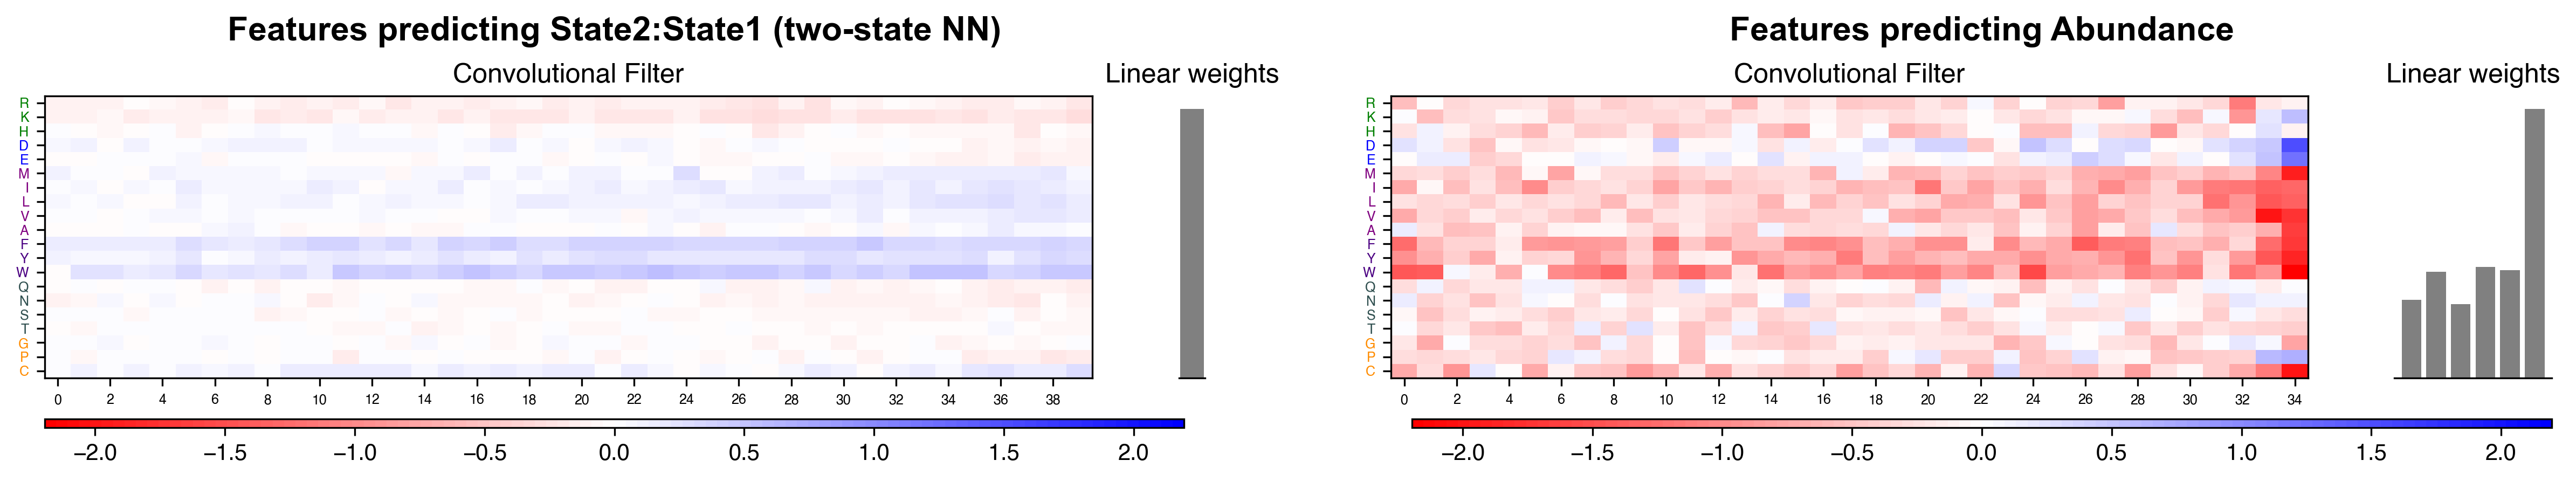

In [19]:
# Get the range for the heatmaps
models = [two_state_biophysical_model]
conv_weights = []

for model in models: 
    conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

# Max value for heatmaps
lim = max([abs(w) for w in conv_weights])

num_rows = 1

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.3] + [3.3]*num_rows + [.1]*2

# Create a gridspec object
gs1 = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)

# Making the first row a title row
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1 (two-state NN)", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting Abundance", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Adding the best NN parameters to the first row
ax1, ax2, ax3, ax4, im1, im2 = make_row_plot_abund(fig, kernel_size_two, two_state_biophysical_model, 1, lim, height_ratios, num_rows+1, abund_k_two)

ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)

# Create another gridspec object to span the whole figure (1 column) to display the colorbar
gs_cb = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[2 + num_rows, 0])
cax2 = plt.subplot(gs_cb[2 + num_rows, 1])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')

plt.savefig('figures/PADI_two_state_parameters_abund.pdf', dpi=1000, bbox_inches='tight')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


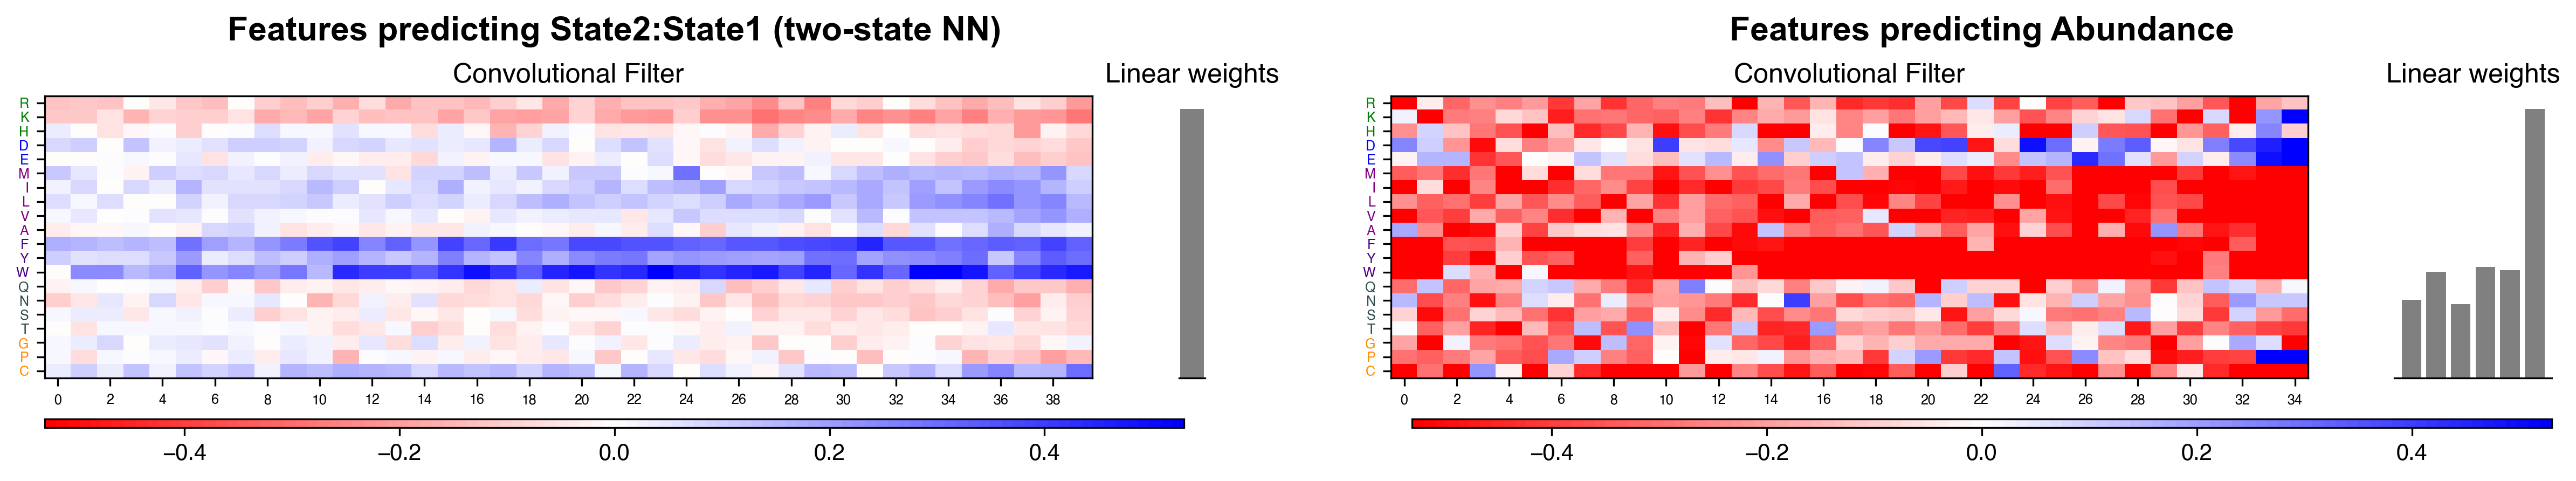

In [20]:
# Get the range for the heatmaps
models = [two_state_biophysical_model]
conv_weights = []

for model in models: 
    conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    # conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

# Max value for heatmaps
lim = max([abs(w) for w in conv_weights])

num_rows = 1

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.3] + [3.3]*num_rows + [.1]*2

# Create a gridspec object
gs1 = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)

# Making the first row a title row
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1 (two-state NN)", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting Abundance", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Adding the best NN parameters to the first row
ax1, ax2, ax3, ax4, im1, im2 = make_row_plot_abund(fig, kernel_size_two, two_state_biophysical_model, 1, lim, height_ratios, num_rows+1, abund_k_two)

ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)

# Create another gridspec object to span the whole figure (1 column) to display the colorbar
gs_cb = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[2 + num_rows, 0])
cax2 = plt.subplot(gs_cb[2 + num_rows, 1])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')

plt.savefig('figures/PADI_two_state_parameters_act.pdf', dpi=1000, bbox_inches='tight')

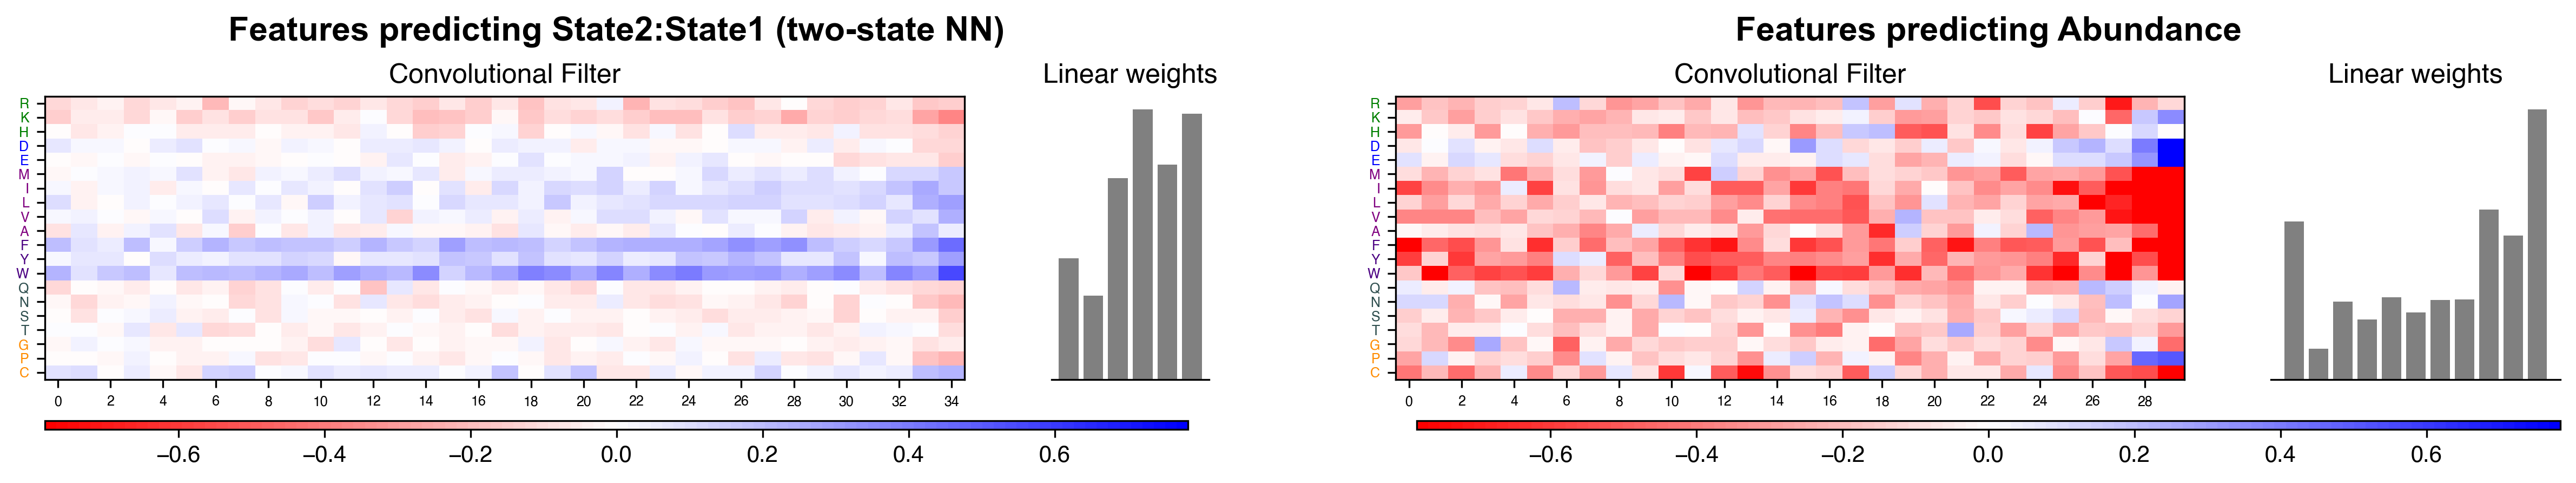

In [65]:
# Get the range for the heatmaps
models = [two_state_biophysical_model_gcn4]
conv_weights_gcn4 = []

for model in models: 
    conv_weights_gcn4 += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    conv_weights_gcn4 += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

# Max value for heatmaps
lim = max([abs(w) for w in conv_weights_gcn4])

num_rows = 1

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.3] + [3.3]*num_rows + [.1]*2

# Create a gridspec object
gs1 = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)

# Making the first row a title row
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1 (two-state NN)", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting Abundance", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Adding the best NN parameters to the first row
ax1, ax2, ax3, ax4, im1, im2 = make_row_plot_abund(fig, kernel_size_two, two_state_biophysical_model, 1, lim, height_ratios, num_rows+1, abund_k_two)

ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)

# Create another gridspec object to span the whole figure (1 column) to display the colorbar
gs_cb = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[2 + num_rows, 0])
cax2 = plt.subplot(gs_cb[2 + num_rows, 1])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')


In [79]:
two_state_biophysical_model

ADModel_two_state_abund(
  (conv2): Conv2d(1, 1, kernel_size=(30, 20), stride=(1, 1))
  (linear2): Linear(in_features=11, out_features=1, bias=True)
  (conv1): Conv2d(1, 1, kernel_size=(35, 20), stride=(1, 1))
  (linear1): Linear(in_features=6, out_features=1, bias=True)
  (activate1): LeakyReLU(negative_slope=0.01)
  (activate2): LeakyReLU(negative_slope=0.01)
  (activate3): LeakyReLU(negative_slope=0.01)
  (activate4): LeakyReLU(negative_slope=0.01)
  (transf): HillActivation()
  (sigmoid): Sigmoid()
)

In [80]:
two_state_biophysical_model_gcn4

ADModel_two_state_abund(
  (conv2): Conv2d(1, 1, kernel_size=(30, 20), stride=(1, 1))
  (linear2): Linear(in_features=11, out_features=1, bias=True)
  (conv1): Conv2d(1, 1, kernel_size=(40, 20), stride=(1, 1))
  (linear1): Linear(in_features=1, out_features=1, bias=True)
  (activate1): LeakyReLU(negative_slope=0.01)
  (activate2): LeakyReLU(negative_slope=0.01)
  (activate3): LeakyReLU(negative_slope=0.01)
  (activate4): LeakyReLU(negative_slope=0.01)
  (transf): HillActivation()
  (sigmoid): Sigmoid()
)

In [73]:
len(padi_weights)

700

In [74]:
len(gcn4_weights)

800

In [94]:
pearsonr(gcn4_weights, padi_weights)

PearsonRResult(statistic=-0.8485585, pvalue=8.055410925136444e-223)

PearsonRResult(statistic=-0.8485585, pvalue=8.055410925136444e-223)

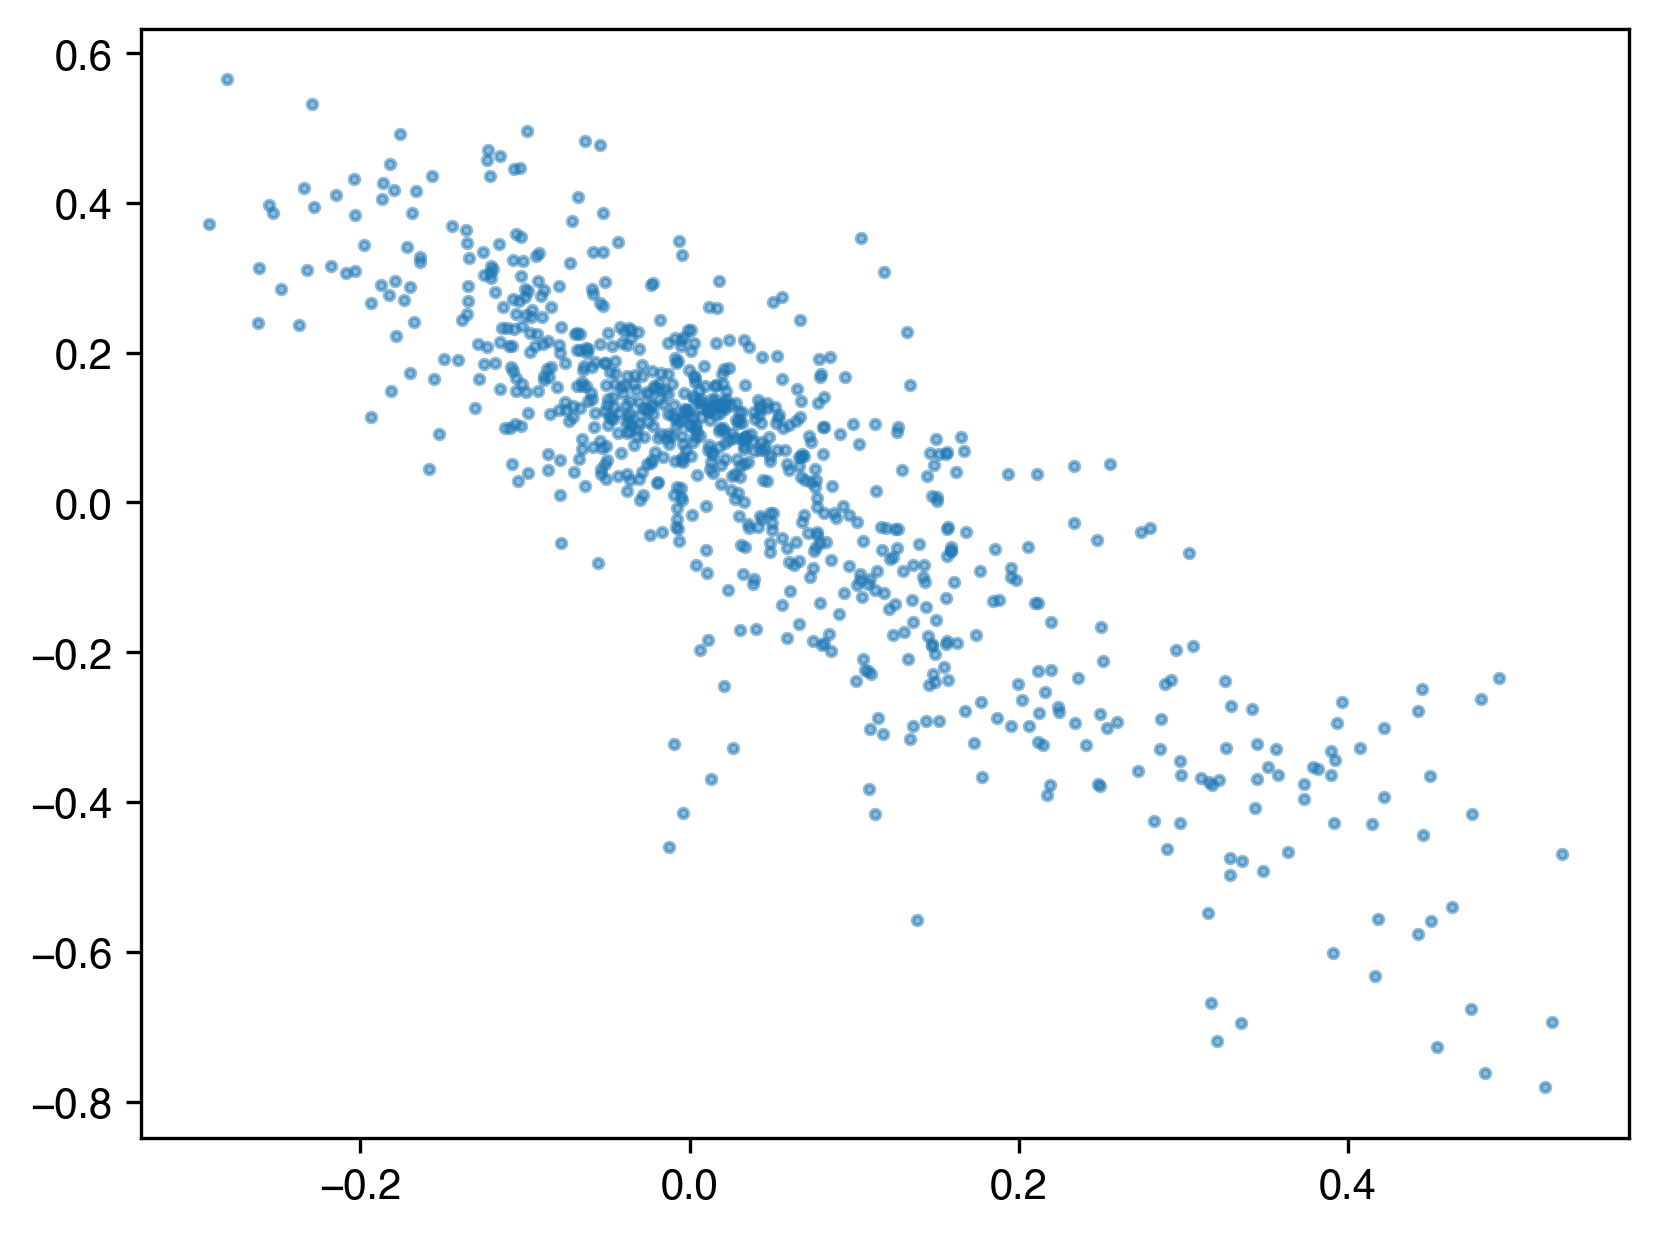

In [95]:
padi_weights = list(get_conv_weights(two_state_biophysical_model, "conv1.weight").T.values.flatten())
gcn4_weights = list(get_conv_weights(two_state_biophysical_model_gcn4, "conv1.weight").T.values.flatten())
plt.scatter(padi_weights, gcn4_weights, s=5, alpha=0.5)
pearsonr(gcn4_weights, padi_weights)

<BarContainer object of 20 artists>

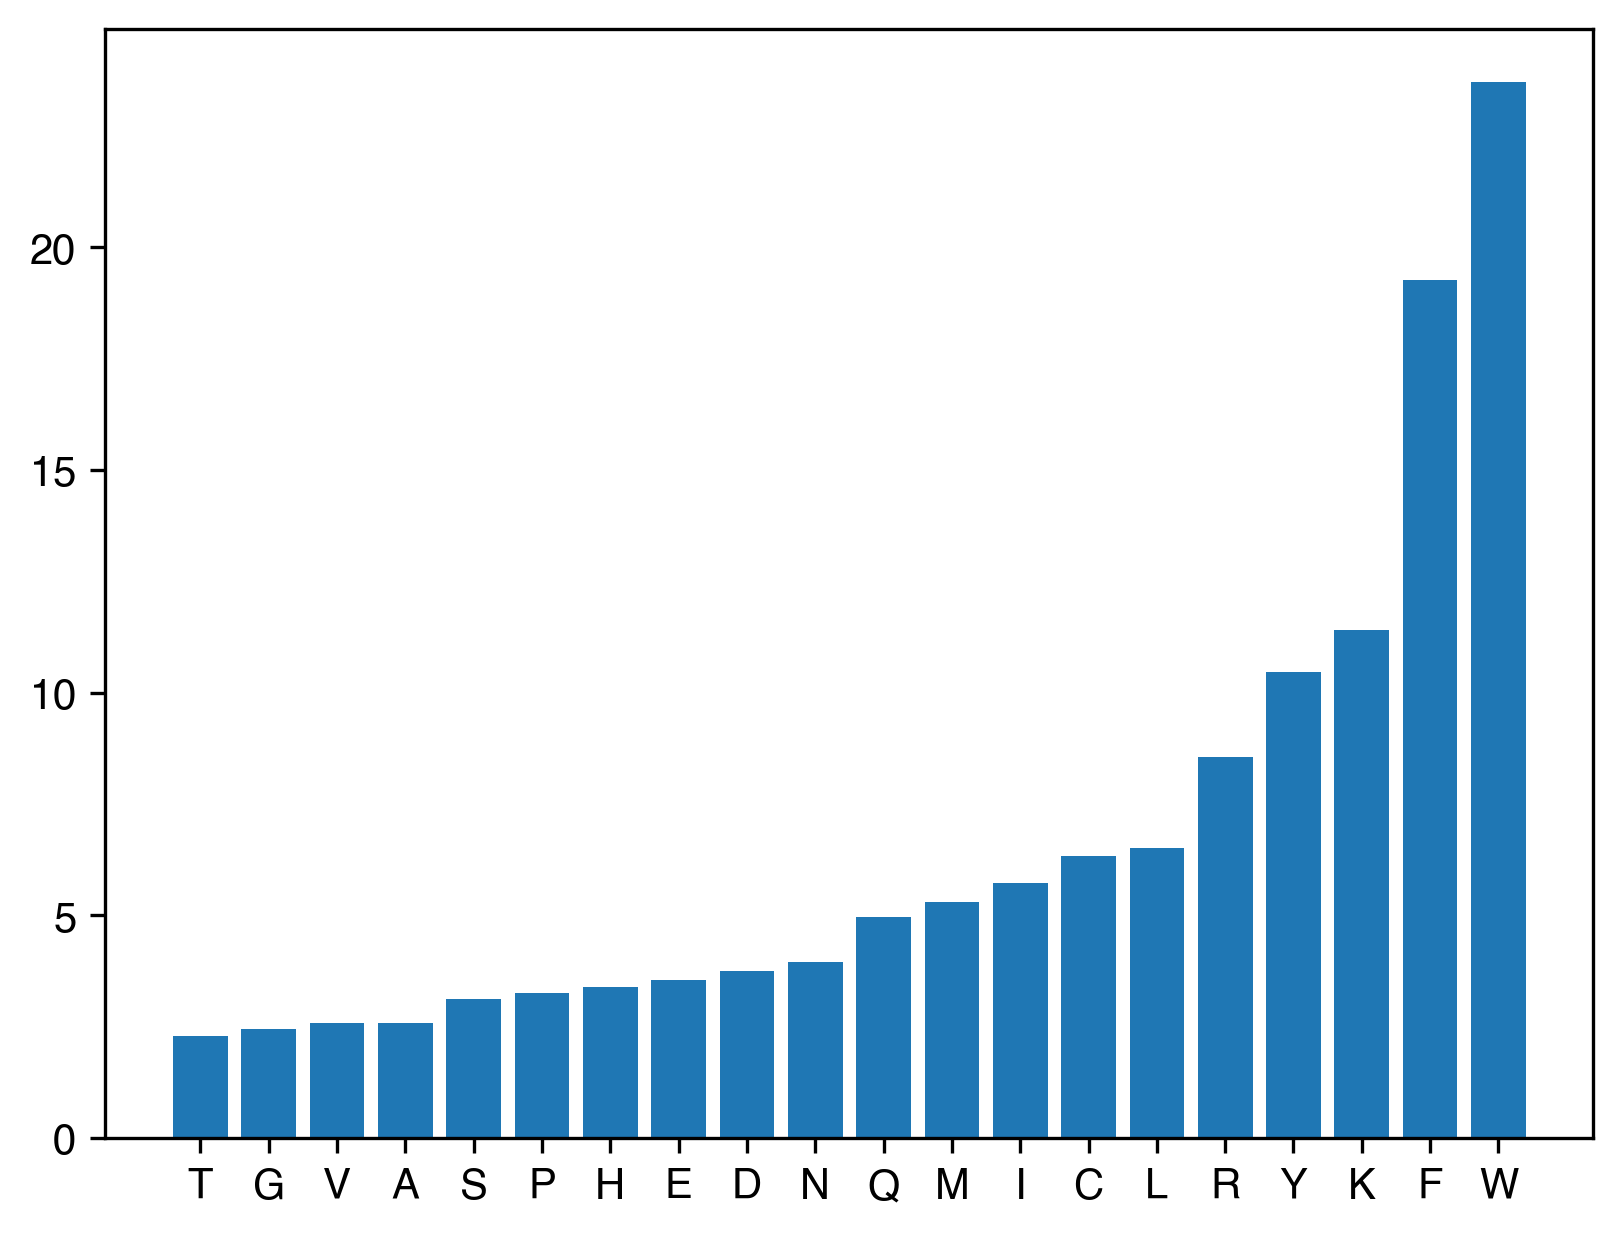

In [26]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')

# Control could be to shuffle row wise
plt.bar(np.abs(conv_weights).sum().sort_values().index, height=np.abs(conv_weights).sum().sort_values())

# Testing on Gcn4 tile data

In [46]:
tile_data = pd.read_csv("Data/pm_gcn4_sort2_pools_allchannels_wrangled_w_ratio.csv")

In [47]:
tile_data["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0] for tile in tile_data["aa_seq"]]
tile_data["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tile_data["aa_seq"]]

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


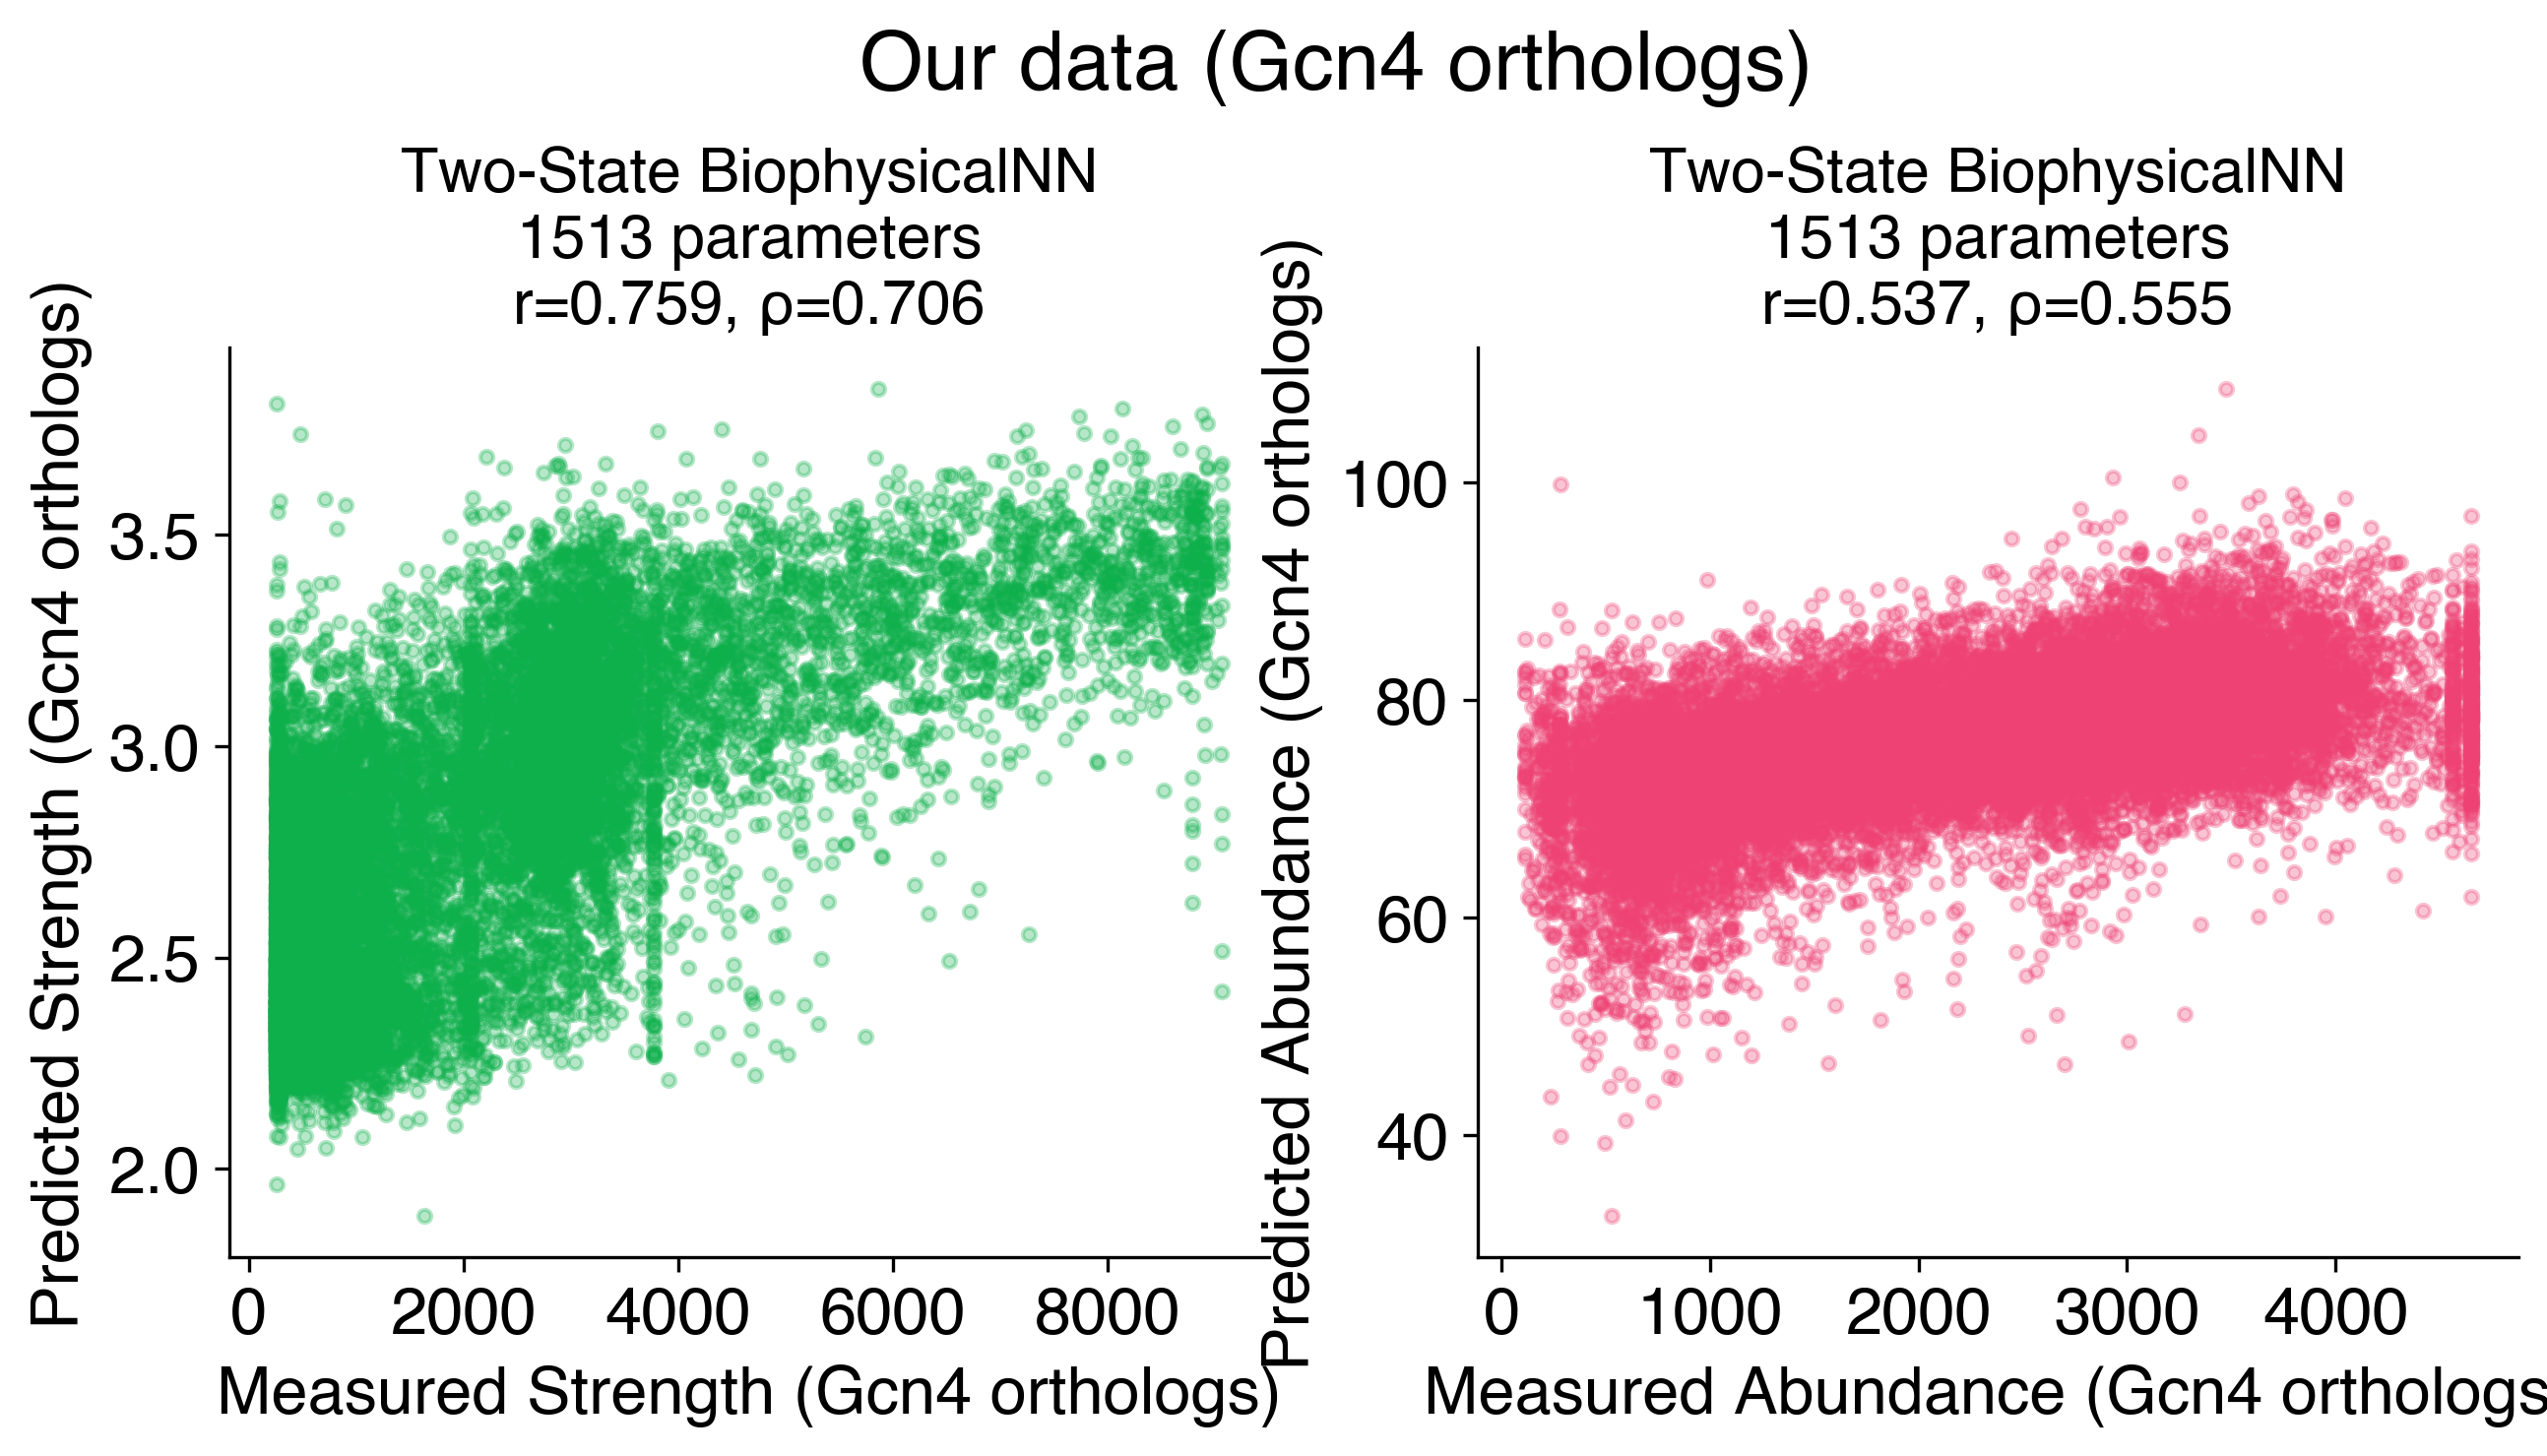

In [48]:
# Code to plot scatter plots for two-state BiophysicalNN, and ADHunter

fig, axs = plt.subplots(1,2,figsize=(10,4))

# Scatter plot for two-state BiophysicalNN - GFP
tiles = tile_data['aa_seq'] 

actual = tile_data['activity']
pred = tile_data["biophysics_gfp_pred_2"] 

plotting_data = pd.DataFrame((actual, pred, tiles)).T
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[0].scatter(actual, pred, color='#0DB04B', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[0].set_xlabel('Measured Strength (Gcn4 orthologs)', fontsize=16)
axs[0].set_ylabel('Predicted Strength (Gcn4 orthologs)', fontsize=16)
axs[0].set_title("Two-State BiophysicalNN" + f'\n{best_params} parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)
axs[0].tick_params(labelsize=16)

# Scatter plot for two-state BiophysicalNN - mCherry
tiles = tile_data['aa_seq'] 

actual = tile_data['abundance']
pred = tile_data["biophysics_mcherry_pred_2"] 

plotting_data = pd.DataFrame((actual, pred, tiles)).T
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[1].scatter(actual, pred, color='#EE4274', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[1].set_xlabel('Measured Abundance (Gcn4 orthologs)', fontsize=16)
axs[1].set_ylabel('Predicted Abundance (Gcn4 orthologs)', fontsize=16)
axs[1].set_title("Two-State BiophysicalNN" + f'\n{best_params} parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)
axs[1].tick_params(labelsize=16)

fig.suptitle("Our data (Gcn4 orthologs)", y=1.15, fontsize=20)

sns.despine()
plt.savefig("figures/PADI_trained_on_Gcn4_two_state_scatter_plots.pdf", format='pdf', bbox_inches='tight')